In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

def regression_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def classification_metrics(y_true, y_pred_prob, threshold=0.5):
    y_class = (y_pred_prob >= threshold).astype(int)
    mse = np.mean((y_true - y_pred_prob) ** 2)
    acc = np.mean(y_class == y_true)
    return mse, acc

# 1. Classifying 1D data with a single Neuron

## Loading the Data

In [2]:
data = np.loadtxt("1d_classification_single_neuron.csv", delimiter=",")
x = data[:, 0]
y_gt = data[:, 1]

print("x shape:", x.shape)
print("y_gt shape:", y_gt.shape)
print("x:", x[:5])
print("y_gt:", y_gt[:5])

x shape: (100,)
y_gt shape: (100,)
x: [-0.09118547  0.13565954 -0.06775434  0.09773268  0.93590398]
y_gt: [0. 1. 0. 0. 1.]


## Visualizing the Data

In [3]:
# Helpers for continuous sigmoid outputs [0,1] as sorted line
def plot_data_1d(x, y_gt, title="Training data"):
    plt.figure(figsize=(8, 4))
    plt.scatter(x, y_gt, s=35, c="k")
    plt.xlabel("x")
    plt.ylabel("class")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()

def plot_pred_1d(x, y_gt, y_p, title="Prediction"):
    order = np.argsort(x)
    plt.figure(figsize=(8, 4))
    plt.scatter(x, y_gt, s=35, c="k", label="ground truth")
    plt.plot(x[order], y_p[order], linewidth=2, label="sigmoid prediction")
    plt.axhline(0.5, linestyle="--", linewidth=1, label="threshold = 0.5")
    plt.xlabel("x")
    plt.ylabel("output")
    plt.title(title)
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

## (a) Implementing a Single Neuron

Create a single neuron with one scalar weigth `w0` and one input `x` (which can be a scalar or a vector corresponding to multiple inputs) ...

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def neuron_clas_1d(w, b, x):
    return sigmoid(w * x + b)

def squared_error(y_true, y_pred):
    return (y_true - y_pred) ** 2

... randomly initialize its weight ...

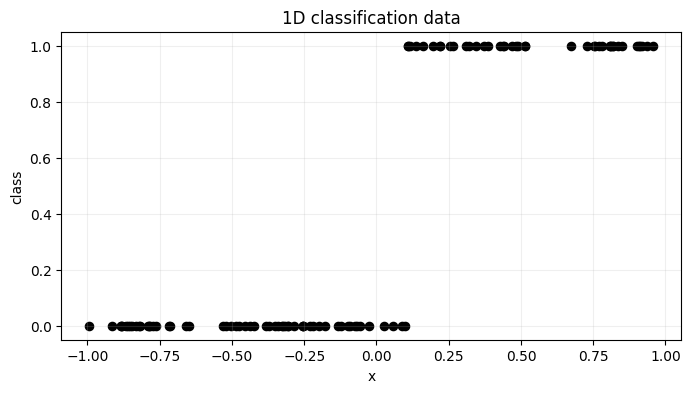

In [5]:
plot_data_1d(x, y_gt, title="1D classification data")

## (b) Random initialization of both weight and bias

initial w = 0.30471707975443135
initial b = -1.0399841062404955


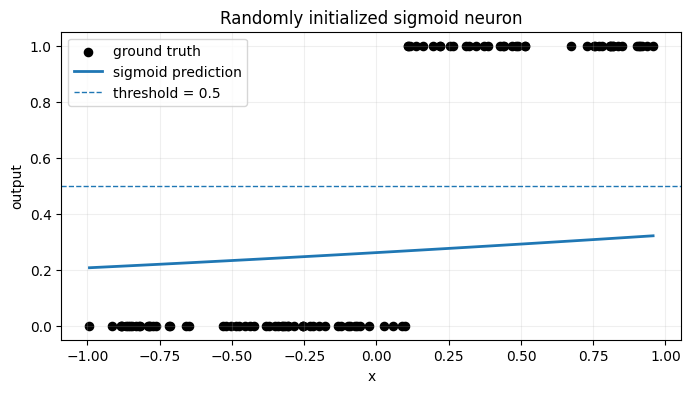

In [6]:
rng = default_rng(42)
w = rng.standard_normal()
b = rng.standard_normal()

print("initial w =", w)
print("initial b =", b)

y_p = neuron_clas_1d(w, b, x)
plot_pred_1d(x, y_gt, y_p, title="Randomly initialized sigmoid neuron")

## (c) Gradient components for updating via chain rule

If loss is E = (y_true - y_pred)^2, then dE/dy_pred = 2 * (y_pred - y_true)

y_pred = sigmoid(z) with z = wx + b, the derivative dy_pred/dz = y_pred * (1 - y_pred)

In [7]:
# Gradients
def dE_dy(y_true, y_pred):
    return 2.0 * (y_pred - y_true)

def dy_dz(y_pred):
    return y_pred * (1.0 - y_pred)

def gradients_single_sample(x_i, y_true, w, b):
    y_pred = neuron_clas_1d(w, b, x_i)
    delta = dE_dy(y_true, y_pred) * dy_dz(y_pred)
    grad_w = delta * x_i
    grad_b = delta
    err = squared_error(y_true, y_pred)
    return y_pred, err, grad_w, grad_b

In [8]:
# sanity check
test_idx = 0
y_pred_0, err_0, grad_w_0, grad_b_0 = gradients_single_sample(x[test_idx], y_gt[test_idx], w, b)

print("sample x:", x[test_idx])
print("sample y_true:", y_gt[test_idx])
print("sample y_pred:", y_pred_0)
print("sample error:", err_0)
print("grad_w:", grad_w_0)
print("grad_b:", grad_b_0)

sample x: -0.09118547041490999
sample y_true: 0.0
sample y_pred: 0.25582742328949887
sample error: 0.06544767050694443
grad_w: -0.008882260247663266
grad_b: 0.09740872320170542


## (d) stochastic single sample training

In [9]:
w = rng.standard_normal()
b = rng.standard_normal()

num_samples = len(x)
num_train_iterations = 100_000
eta = 0.01

error_history = np.zeros(num_train_iterations)

for i in range(num_train_iterations):
    idx = rng.integers(0, num_samples)
    x_i = x[idx]
    y_i = y_gt[idx]
    y_pred_i, err_i, grad_w, grad_b = gradients_single_sample(x_i, y_i, w, b)
    w -= eta * grad_w
    b -= eta * grad_b
    error_history[i] = err_i

print("trained w =", w)
print("trained b =", b)

trained w = 8.179435341695976
trained b = -0.6361471953269089


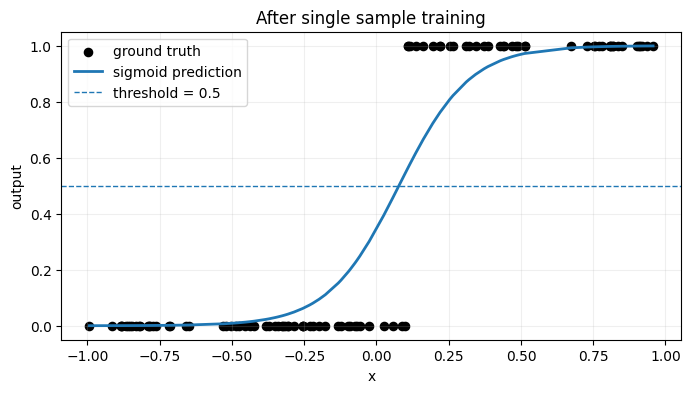

In [10]:
# performance plot
y_p_trained = neuron_clas_1d(w, b, x)
plot_pred_1d(x, y_gt, y_p_trained, title="After single sample training")

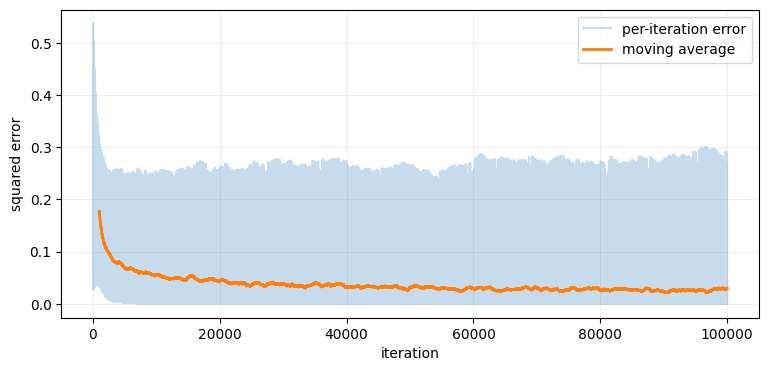

In [11]:
# Training error history plot
plt.figure(figsize=(9, 4))
plt.plot(error_history, alpha=0.25, label="per-iteration error")

# iterations average
window = 1000
smoothed = np.convolve(error_history, np.ones(window) / window, mode="valid")
plt.plot(np.arange(window - 1, len(error_history)), smoothed, linewidth=2, label="moving average")

plt.xlabel("iteration")
plt.ylabel("squared error")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## (e) batch-gradient

In [12]:
def batch_gradients(x_batch, y_batch, w, b):
    y_pred = neuron_clas_1d(w, b, x_batch)
    errors = squared_error(y_batch, y_pred)
    delta = 2.0 * (y_pred - y_batch) * y_pred * (1.0 - y_pred)
    grad_w = np.mean(delta * x_batch)
    grad_b = np.mean(delta)
    batch_error = np.mean(errors)
    return y_pred, batch_error, grad_w, grad_b

def train_batch(x, y_gt, batch_size=16, eta=0.05, num_batches=10_000, seed=42):
    rng_local = default_rng(seed)
    w = rng_local.standard_normal()
    b = rng_local.standard_normal()
    batch_error_history = np.zeros(num_batches)

    for i in range(num_batches):
        idx = rng_local.integers(0, len(x), size=batch_size)
        x_batch = x[idx]
        y_batch = y_gt[idx]
        _, batch_error, grad_w, grad_b = batch_gradients(x_batch, y_batch, w, b)
        w -= eta * grad_w
        b -= eta * grad_b
        batch_error_history[i] = batch_error

    return w, b, batch_error_history

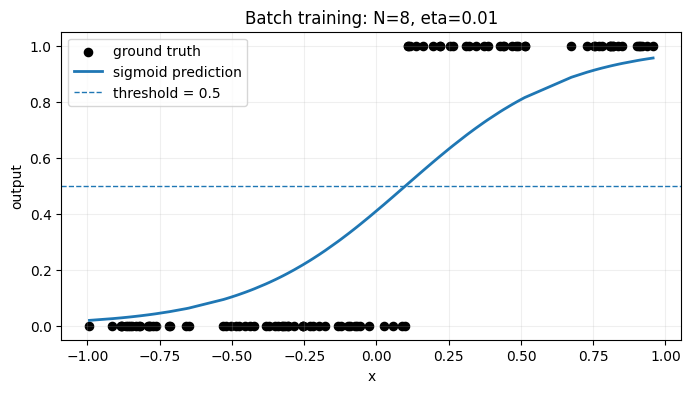

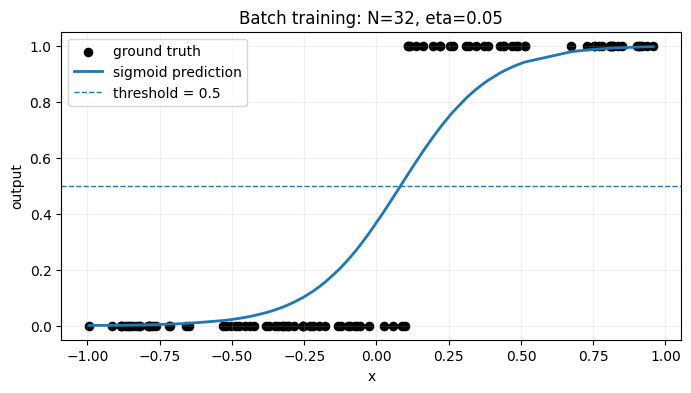

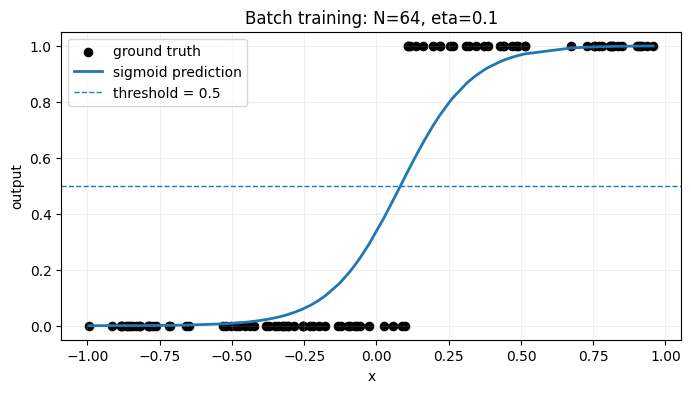

In [13]:
# to compare different batch sizes and learning rates
experiments = [
    (8, 0.01),
    (32, 0.05),
    (64, 0.10),
]

results = {}

for batch_size, eta in experiments:
    w_b, b_b, err_b = train_batch(x, y_gt, batch_size=batch_size, eta=eta, num_batches=10_000, seed=42)
    results[(batch_size, eta)] = (w_b, b_b, err_b)

    y_p_b = neuron_clas_1d(w_b, b_b, x)
    plot_pred_1d(x, y_gt, y_p_b, title=f"Batch training: N={batch_size}, eta={eta}")

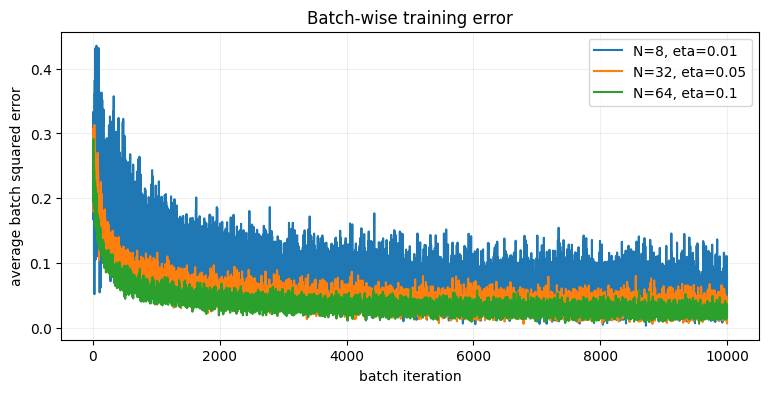

In [14]:
# compare the error curves
plt.figure(figsize=(9, 4))

for (batch_size, eta), (_, _, err_b) in results.items():
    plt.plot(err_b, label=f"N={batch_size}, eta={eta}")

plt.xlabel("batch iteration")
plt.ylabel("average batch squared error")
plt.title("Batch-wise training error")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [15]:
y_final = neuron_clas_1d(w, b, x)
y_class = (y_final >= 0.5).astype(int)
print("Training MSE:", np.mean((y_gt - y_final)**2))
print("Training accuracy:", np.mean(y_class == y_gt))

Training MSE: 0.025146778227621104
Training accuracy: 0.98


In [16]:
for (N, eta), (w_b, b_b, err_b) in results.items():
    y_pred = neuron_clas_1d(w_b, b_b, x)
    y_class = (y_pred >= 0.5).astype(int)
    mse = np.mean((y_gt - y_pred)**2)
    acc = np.mean(y_class == y_gt)
    print(f"N={N}, eta={eta} -> MSE={mse:.4f}, accuracy={acc:.4f}")

N=8, eta=0.01 -> MSE=0.0542, accuracy=1.0000
N=32, eta=0.05 -> MSE=0.0310, accuracy=0.9800
N=64, eta=0.1 -> MSE=0.0252, accuracy=0.9800


# 2. Classifying 2D data with single Neuron

In [17]:
data = np.loadtxt("2d_classification_single_neuron.csv", delimiter=",")
x1 = data[:, 0]
x2 = data[:, 1]
y_gt = data[:, 2]

# Combine the two input columns into one input matrix- Shape (num_samples, 2)
x = np.column_stack((x1, x2))
print("x shape:", x.shape)
print("y_gt shape:", y_gt.shape)
print("first 5 x rows:\n", x[:5])
print("first 5 y_gt:", y_gt[:5])

x shape: (100, 2)
y_gt shape: (100,)
first 5 x rows:
 [[ 0.04177092 -0.39827782]
 [-0.89471091  0.85793277]
 [ 0.32661227 -0.10991945]
 [ 0.65323643  0.31083676]
 [ 0.37978177 -0.24913824]]
first 5 y_gt: [1. 0. 1. 1. 1.]


## a) Plotting 2D data

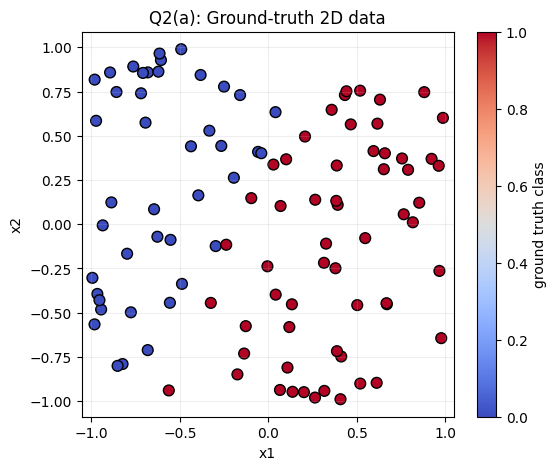

In [18]:
def plot_data_2d(x, y_gt, title="2D classification data"):
    """
    Plot the ground-truth classes in the x1-x2 plane.
    Class 0 and class 1 are shown using different colours.
    """
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(x[:, 0], x[:, 1], c=y_gt, cmap="coolwarm", s=60, edgecolor="k")
    plt.colorbar(sc, label="ground truth class")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.show()

plot_data_2d(x, y_gt, title="Q2(a): Ground-truth 2D data")

## b) define a 2D neuron and plot random predictions

In [19]:
# Sigmoid neuron for 2D input
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def neuron_clas_2d(w, b, x):
    return sigmoid(x @ w + b)

def squared_error(y_true, y_pred):
    return (y_true - y_pred) ** 2

def plot_pred_2d(x, y_gt, y_pred, title="Prediction of 2D neuron"):
    plt.figure(figsize=(12, 5))
    # Left: ground truth
    plt.subplot(1, 2, 1)
    sc1 = plt.scatter(x[:, 0], x[:, 1], c=y_gt, cmap="coolwarm", s=60, edgecolor="k")
    plt.colorbar(sc1, label="ground truth class")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Ground truth")
    plt.axis("equal")
    plt.grid(alpha=0.2)

    # Right: model prediction
    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(x[:, 0], x[:, 1], c=y_pred, cmap="coolwarm", s=60, edgecolor="k", vmin=0, vmax=1)
    plt.colorbar(sc2, label="predicted output")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

initial w = [ 0.30471708 -1.03998411]
initial b = 0.7504511958064572


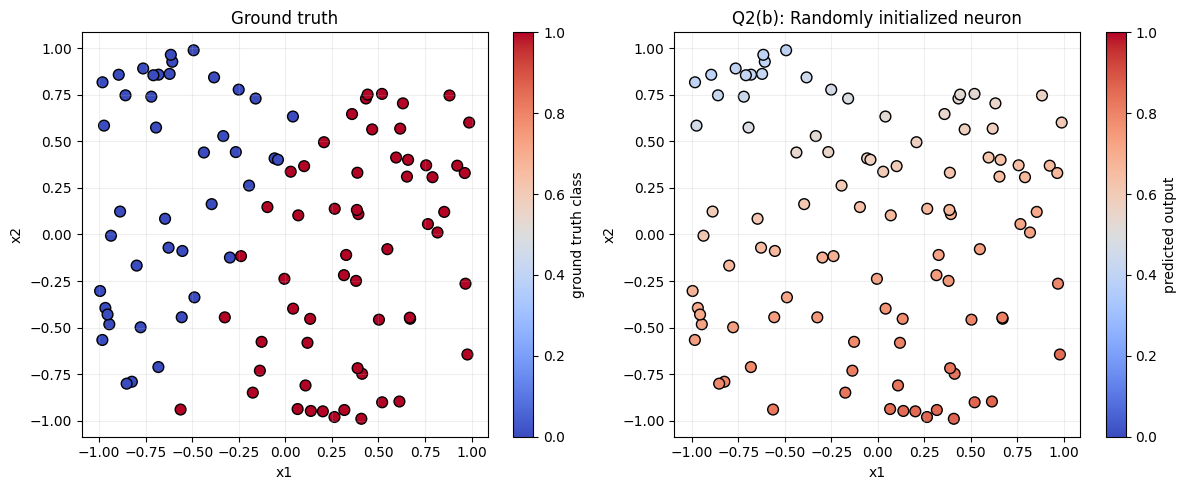

In [20]:
# Random initialization of weights and bias
rng = default_rng(42)

# Two weights now, because input has two features
w = rng.standard_normal(2)   # shape (2,)
b = rng.standard_normal()    # scalar

print("initial w =", w)
print("initial b =", b)

# Prediction of randomly initialized neuron on all data
y_pred_random = neuron_clas_2d(w, b, x)
plot_pred_2d(x, y_gt, y_pred_random, title="Q2(b): Randomly initialized neuron")

## c) Gradients, training loop, error plot, final prediction

In [21]:
# defining again gradient helpers
def dE_dy(y_true, y_pred):
    """
    Derivative of squared error:
        E = (y_true - y_pred)^2
        dE/dy_pred = 2*(y_pred - y_true)
    """
    return 2.0 * (y_pred - y_true)

def dy_dz(y_pred):
    """
    Derivative of sigmoid:
        sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z))
    We already have y_pred = sigmoid(z),
        dy/dz = y_pred * (1 - y_pred)
    """
    return y_pred * (1.0 - y_pred)

def gradients_single_sample_2d(x_i, y_true, w, b):
    """
    Compute prediction, error, and gradients for 1 sample.
    x_i has shape (2,)
    w has shape (2,)
    b is scalar
    """
    y_pred = neuron_clas_2d(w, b, x_i)
    # Chain rule term
    delta = dE_dy(y_true, y_pred) * dy_dz(y_pred)
    # Since z = x_i @ w + b:
    # dE/dw = delta * x_i
    # dE/db = delta
    grad_w = delta * x_i
    grad_b = delta

    err = squared_error(y_true, y_pred)
    return y_pred, err, grad_w, grad_b

In [22]:
test_idx = 0
y_pred_0, err_0, grad_w_0, grad_b_0 = gradients_single_sample_2d(x[test_idx], y_gt[test_idx], w, b)

print("sample x:", x[test_idx])
print("sample y_true:", y_gt[test_idx])
print("sample y_pred:", y_pred_0)
print("sample error:", err_0)
print("grad_w:", grad_w_0)
print("grad_b:", grad_b_0)

sample x: [ 0.04177092 -0.39827782]
sample y_true: 1.0
sample y_pred: 0.7644767735526463
sample error: 0.055471190196171444
grad_w: [-0.00354271  0.03377909]
grad_b: -0.08481287301258866


In [23]:
# Training loop: single-sample stochastic updates
# Homework hint: eta 0.1 for Q2
rng = default_rng(42)
w = rng.standard_normal(2)
b = rng.standard_normal()
num_samples = len(x)
num_train_iterations = 100_000
eta = 0.1

error_history = np.zeros(num_train_iterations)

for i in range(num_train_iterations):
    # random sample
    idx = rng.integers(0, num_samples)
    x_i = x[idx]         # shape (2,)
    y_i = y_gt[idx]      # scalar
    # Compute gradient on this single sample
    y_pred_i, err_i, grad_w, grad_b = gradients_single_sample_2d(x_i, y_i, w, b)
    # Gradient descent update
    w -= eta * grad_w
    b -= eta * grad_b
    # Store error from this iteration
    error_history[i] = err_i

print("trained w =", w)
print("trained b =", b)

trained w = [15.61824271 -8.16834031]
trained b = 3.1514892075981993


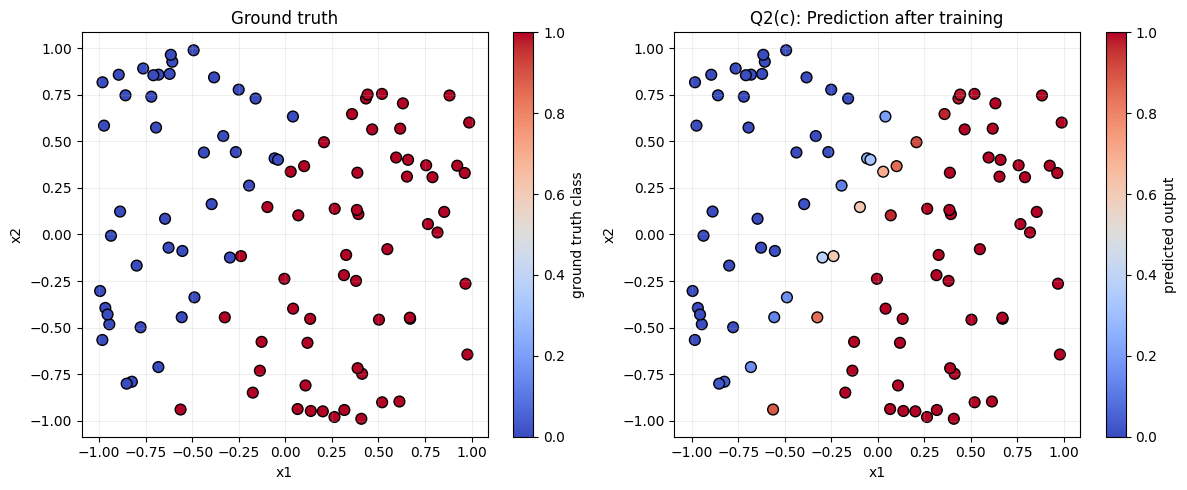

In [24]:
y_pred_trained = neuron_clas_2d(w, b, x)
plot_pred_2d(x, y_gt, y_pred_trained, title="Q2(c): Prediction after training")

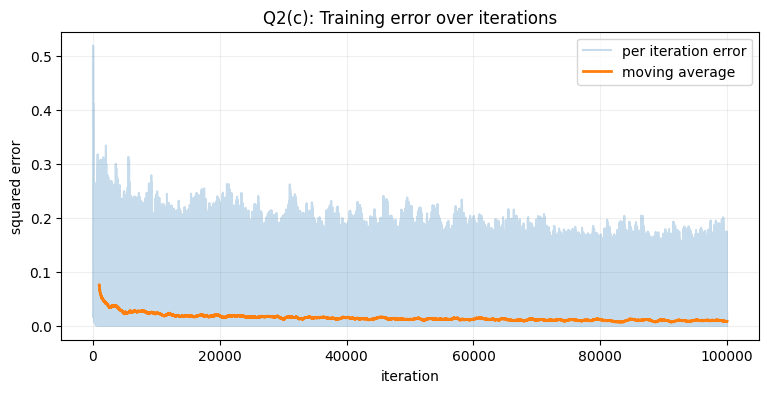

In [25]:
plt.figure(figsize=(9, 4))
plt.plot(error_history, alpha=0.25, label="per iteration error")

window = 1000
smoothed = np.convolve(error_history, np.ones(window) / window, mode="valid")
plt.plot(
    np.arange(window - 1, len(error_history)),
    smoothed,
    linewidth=2,
    label="moving average"
)

plt.xlabel("iteration")
plt.ylabel("squared error")
plt.title("Q2(c): Training error over iterations")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [26]:
mse, acc = classification_metrics(y_gt, y_pred_trained)
print("Training MSE:", mse)
print("Training accuracy:", acc)

Training MSE: 0.00909272657640296
Training accuracy: 1.0


# 3: Two-dimensional classiﬁcation with multiple neurons

In [27]:
data = np.loadtxt("2d_classification_multiple_neurons.csv", delimiter=",")

x = data[:, :2]          # first two columns = inputs
y_gt = data[:, 2:3]      # last column = class, keep as column vector shape (N,1)

print("x shape:", x.shape)
print("y_gt shape:", y_gt.shape)
print("first 5 x rows:\n", x[:5])
print("first 5 y_gt:\n", y_gt[:5])

x shape: (100, 2)
y_gt shape: (100, 1)
first 5 x rows:
 [[ 0.35292617  0.93748562]
 [ 0.82479715  0.1104809 ]
 [-0.70512941 -0.65960378]
 [ 0.88416134 -0.56205933]
 [ 0.13394545 -0.69021742]]
first 5 y_gt:
 [[0.]
 [1.]
 [1.]
 [1.]
 [0.]]


In [28]:
def plot_data_2d(x, y_gt, title="2D classification data"):
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(
        x[:, 0], x[:, 1],
        c=y_gt.ravel(),
        cmap="coolwarm",
        s=60,
        edgecolor="k"
    )
    plt.colorbar(sc, label="ground-truth class")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.show()

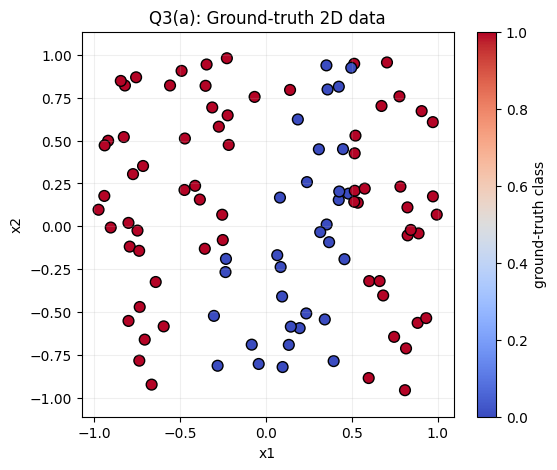

In [29]:
# Q3(a) colour-coded scatter plot of the data
plot_data_2d(x, y_gt, title="Q3(a): Ground-truth 2D data")

In [30]:
# Activation function
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative_from_output(y):
    """
    sigmoid'(z) = y * (1 - y)
    """
    return y * (1.0 - y)

In [31]:
# Two layer neural network with biases for binary classification
def dnn2_clas(W0, b0, Wout, bout, x):
    """
        x     : shape (num_samples, 2) or (1, 2)
        W0    : shape (2, N)
        b0    : shape (N,)
        Wout  : shape (N, 1)
        bout  : shape (1,)

    Forward pass:
        hidden_pre  = x @ W0 + b0
        hidden_out  = sigmoid(hidden_pre)
        out_pre     = hidden_out @ Wout + bout
        y_pred      = sigmoid(out_pre)

    Returns:
        y_pred : shape (num_samples, 1)
    """
    hidden_pre = x @ W0 + b0
    hidden_out = sigmoid(hidden_pre)
    out_pre = hidden_out @ Wout + bout
    y_pred = sigmoid(out_pre)

    return y_pred

In [32]:
# decision surface background for model_fn
def plot_pred_2d(x, y_gt, y_pred, model_fn=None, title="Prediction of 2D network"):
    plt.figure(figsize=(12, 5))
    # Left panel: ground truth
    plt.subplot(1, 2, 1)
    sc1 = plt.scatter(
        x[:, 0], x[:, 1],
        c=y_gt.ravel(),
        cmap="coolwarm",
        s=60,
        edgecolor="k"
    )
    plt.colorbar(sc1, label="ground-truth class")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Ground truth")
    plt.axis("equal")
    plt.grid(alpha=0.2)

    # Right panel: prediction
    plt.subplot(1, 2, 2)
    if model_fn is not None:
        # create a dense grid to visualize the learned nonlinear boundary
        x1_min, x1_max = x[:, 0].min() - 0.2, x[:, 0].max() + 0.2
        x2_min, x2_max = x[:, 1].min() - 0.2, x[:, 1].max() + 0.2

        gx1, gx2 = np.meshgrid(
            np.linspace(x1_min, x1_max, 200),
            np.linspace(x2_min, x2_max, 200)
        )

        grid = np.column_stack((gx1.ravel(), gx2.ravel()))
        grid_pred = model_fn(grid).reshape(gx1.shape)
        plt.contourf(gx1, gx2, grid_pred, levels=30, cmap="coolwarm", alpha=0.35)
        plt.contour(gx1, gx2, grid_pred, levels=[0.5], colors="k", linewidths=2)

    sc2 = plt.scatter(
        x[:, 0], x[:, 1],
        c=y_pred.ravel(),
        cmap="coolwarm",
        s=60,
        edgecolor="k",
        vmin=0,
        vmax=1
    )
    plt.colorbar(sc2, label="predicted output")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [33]:
# Q3(b) random initialization
rng = default_rng(42)

num_neurons = 4   # hidden-layer width; try 3 to 6 if you want
W0 = rng.standard_normal((2, num_neurons))   # first-layer weights
b0 = rng.standard_normal(num_neurons)        # first-layer biases
Wout = rng.standard_normal((num_neurons, 1)) # output-layer weights
bout = rng.standard_normal(1)                # output-layer bias

print("W0 shape:", W0.shape)
print("b0 shape:", b0.shape)
print("Wout shape:", Wout.shape)
print("bout shape:", bout.shape)

W0 shape: (2, 4)
b0 shape: (4,)
Wout shape: (4, 1)
bout shape: (1,)


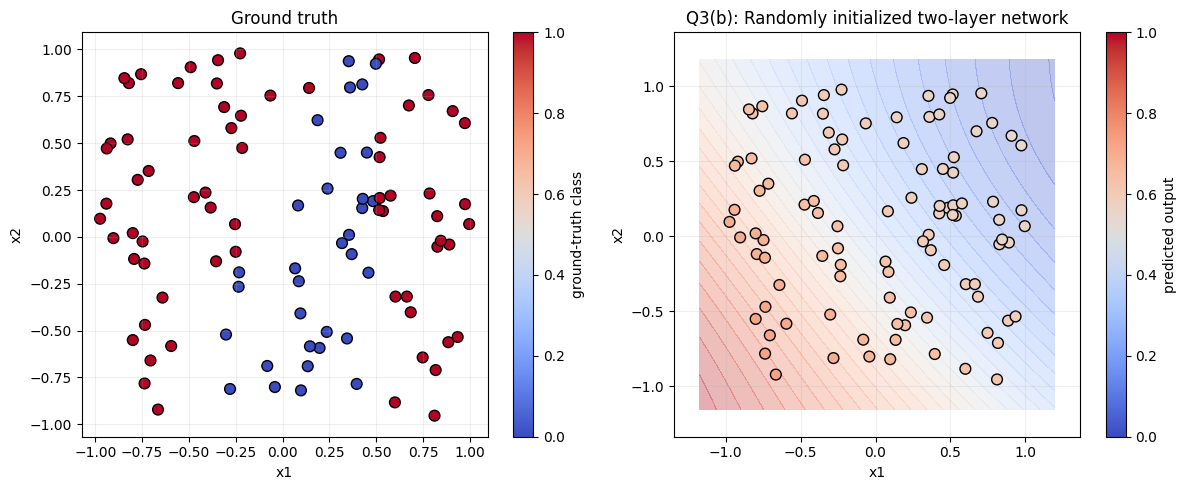

In [34]:
# Random network output on all data
y_pred_random = dnn2_clas(W0, b0, Wout, bout, x)

plot_pred_2d(
    x, y_gt, y_pred_random,
    model_fn=lambda xx: dnn2_clas(W0, b0, Wout, bout, xx),
    title="Q3(b): Randomly initialized two-layer network"
)

In [35]:
# forward pass with intermediate outputs
def forward_two_layer(W0, b0, Wout, bout, x):
    """
    Forward pass that also returns hidden layer output for backpropagation.
    """
    hidden_pre = x @ W0 + b0
    hidden_out = sigmoid(hidden_pre)
    out_pre = hidden_out @ Wout + bout
    y_pred = sigmoid(out_pre)

    return hidden_out, y_pred

In [36]:
# Single-sample gradients for the two-layer network
def gradients_single_sample_q3(x_i, y_true, W0, b0, Wout, bout):
    """
    Compute prediction, error, and gradients for 1 sample
    x_i    : shape (1, 2)
    y_true : shape (1, 1)
    """
    # Forward pass
    hidden_out, y_pred = forward_two_layer(W0, b0, Wout, bout, x_i)
    # Squared error for one sample
    err = (y_true - y_pred) ** 2

    # Output layer backprop
    dE_dy = 2.0 * (y_pred - y_true)                          # shape (1,1)
    delta_out = dE_dy * sigmoid_derivative_from_output(y_pred)  # shape (1,1)
    grad_Wout = hidden_out.T @ delta_out                    # (N,1)
    grad_bout = delta_out.ravel()                           # (1,)

    # Hidden layer backprop
    delta0 = (delta_out @ Wout.T) * sigmoid_derivative_from_output(hidden_out)  # (1,N)
    grad_W0 = x_i.T @ delta0                                # (2,N)
    grad_b0 = delta0.ravel()                                # (N,)

    return y_pred, err, grad_W0, grad_b0, grad_Wout, grad_bout

In [37]:
test_idx = 0
x_i = x[test_idx:test_idx+1]         # shape (1,2)
y_i = y_gt[test_idx:test_idx+1]      # shape (1,1)

y_pred_0, err_0, grad_W0_0, grad_b0_0, grad_Wout_0, grad_bout_0 = gradients_single_sample_q3(x_i, y_i, W0, b0, Wout, bout)

print("sample x_i:", x_i)
print("sample y_true:", y_i)
print("sample y_pred:", y_pred_0)
print("sample error:", err_0)
print("grad_W0 shape:", grad_W0_0.shape)
print("grad_b0 shape:", grad_b0_0.shape)
print("grad_Wout shape:", grad_Wout_0.shape)
print("grad_bout shape:", grad_bout_0.shape)

sample x_i: [[0.35292617 0.93748562]]
sample y_true: [[0.]]
sample y_pred: [[0.55925426]]
sample error: [[0.31276533]]
grad_W0 shape: (2, 4)
grad_b0 shape: (4,)
grad_Wout shape: (4, 1)
grad_bout shape: (1,)


In [38]:
rng = default_rng(42)
num_neurons = 2
W0 = rng.standard_normal((2, num_neurons))
b0 = rng.standard_normal(num_neurons)
Wout = rng.standard_normal((num_neurons, 1))
bout = rng.standard_normal(1)
num_samples = len(x)
num_train_iterations = 100_000
eta = 0.1
error_history = np.zeros(num_train_iterations)

# training loop
for i in range(num_train_iterations):
    # one random sample
    idx = rng.integers(0, num_samples)
    x_i = x[idx:idx+1]      # shape (1,2)
    y_i = y_gt[idx:idx+1]   # shape (1,1)
    y_pred_i, err_i, grad_W0, grad_b0, grad_Wout, grad_bout = gradients_single_sample_q3(x_i, y_i, W0, b0, Wout, bout)

    # gradient descent update
    Wout -= eta * grad_Wout
    bout -= eta * grad_bout
    W0 -= eta * grad_W0
    b0 -= eta * grad_b0
    error_history[i] = err_i.item()

y_pred_trained = dnn2_clas(W0, b0, Wout, bout, x)
mse, acc = classification_metrics(y_gt, y_pred_trained)
print("Training MSE:", mse)
print("Training accuracy:", acc)

Training MSE: 0.00936322722880634
Training accuracy: 1.0


In [39]:
rng = default_rng(42)
num_neurons = 4
W0 = rng.standard_normal((2, num_neurons))
b0 = rng.standard_normal(num_neurons)
Wout = rng.standard_normal((num_neurons, 1))
bout = rng.standard_normal(1)
num_samples = len(x)
num_train_iterations = 100_000
eta = 0.1
error_history = np.zeros(num_train_iterations)

# training loop
for i in range(num_train_iterations):
    # one random sample
    idx = rng.integers(0, num_samples)
    x_i = x[idx:idx+1]      # shape (1,2)
    y_i = y_gt[idx:idx+1]   # shape (1,1)
    y_pred_i, err_i, grad_W0, grad_b0, grad_Wout, grad_bout = gradients_single_sample_q3(x_i, y_i, W0, b0, Wout, bout)

    # gradient descent update
    Wout -= eta * grad_Wout
    bout -= eta * grad_bout
    W0 -= eta * grad_W0
    b0 -= eta * grad_b0
    error_history[i] = err_i.item()

y_pred_trained = dnn2_clas(W0, b0, Wout, bout, x)
mse, acc = classification_metrics(y_gt, y_pred_trained)
print("Training MSE:", mse)
print("Training accuracy:", acc)

Training MSE: 0.008549517012587288
Training accuracy: 1.0


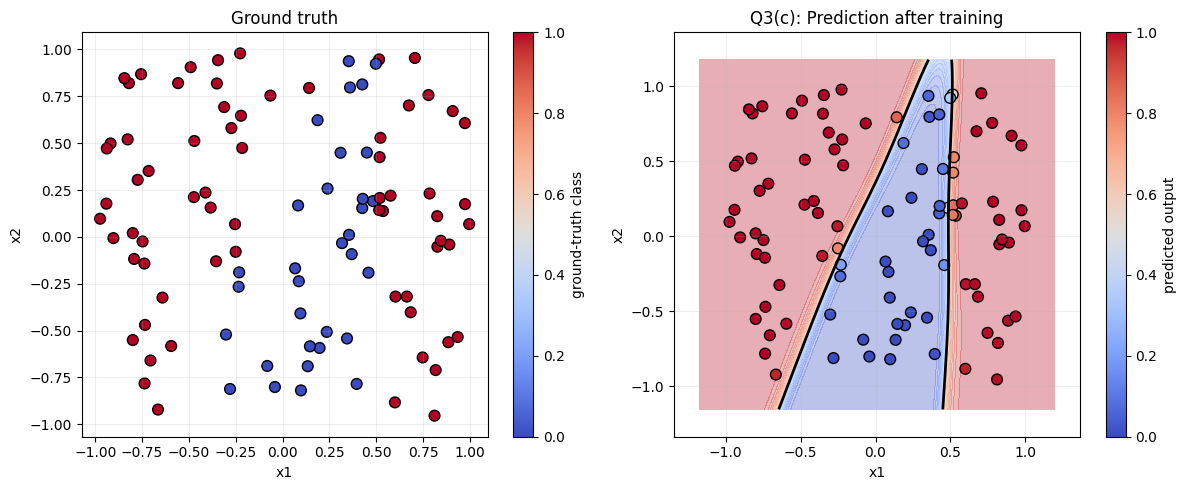

In [40]:
plot_pred_2d(
    x, y_gt, y_pred_trained,
    model_fn=lambda xx: dnn2_clas(W0, b0, Wout, bout, xx),
    title="Q3(c): Prediction after training"
)

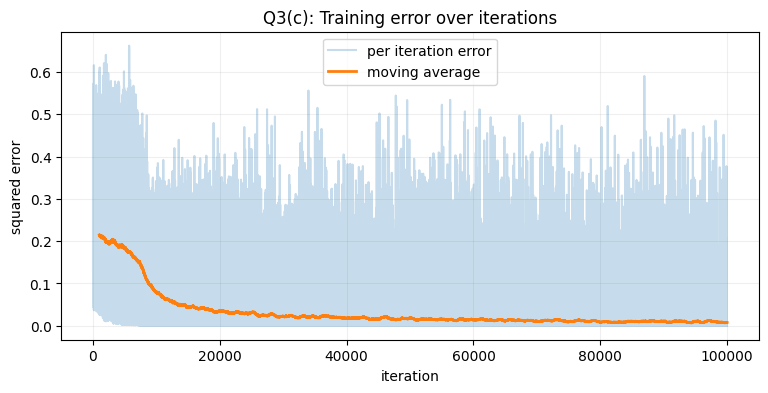

In [41]:
plt.figure(figsize=(9, 4))
plt.plot(error_history, alpha=0.25, label="per iteration error")
window = 1000
smoothed = np.convolve(error_history, np.ones(window) / window, mode="valid")

plt.plot(
    np.arange(window - 1, len(error_history)),
    smoothed,
    linewidth=2,
    label="moving average"
)

plt.xlabel("iteration")
plt.ylabel("squared error")
plt.title("Q3(c): Training error over iterations")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# 4: Function approximation

In [42]:
data = np.loadtxt("function_approximation.csv", delimiter=",")

# Keep both as column vectors for cleaner matrix code later
x = data[:, 0:1]      # shape (N, 1)
y_gt = data[:, 1:2]   # shape (N, 1)

print("x shape:", x.shape)
print("y_gt shape:", y_gt.shape)
print("first 5 x values:\n", x[:5])
print("first 5 y values:\n", y_gt[:5])
print("y min:", y_gt.min(), "y max:", y_gt.max())

x shape: (50, 1)
y_gt shape: (50, 1)
first 5 x values:
 [[-2.        ]
 [-1.91836735]
 [-1.83673469]
 [-1.75510204]
 [-1.67346939]]
first 5 y values:
 [[ 0.22288991]
 [ 0.87234069]
 [ 0.96476195]
 [ 0.55007439]
 [-0.08751399]]
y min: -0.9705199027946775 y max: 0.9979258100857765


In [43]:
def plot_function_1d(x, y_gt, title="Function data"):
    """
    Scatter plot of the given function samples.
    """
    order = np.argsort(x.ravel())

    plt.figure(figsize=(8, 4))
    plt.scatter(x, y_gt, s=40, c="k", label="data")
    plt.plot(x[order], y_gt[order], linewidth=1.5, alpha=0.7, label="sorted guide")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

def plot_prediction_1d(x, y_gt, y_pred, title="Function approximation"):
    """
    Plot target function and neural-network prediction.
    """
    order = np.argsort(x.ravel())

    plt.figure(figsize=(8, 4))
    plt.scatter(x, y_gt, s=35, c="k", label="ground truth")
    plt.plot(x[order], y_gt[order], linewidth=1.5, alpha=0.6, label="ground-truth curve")
    plt.plot(x[order], y_pred[order], linewidth=2.5, label="network prediction")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

def plot_error_history(error_history, title="Training error history", window=1000):
    """
    Plot raw error and a moving average for readability.
    """
    plt.figure(figsize=(9, 4))
    plt.plot(error_history, alpha=0.25, label="per-iteration squared error")

    if len(error_history) >= window:
        smoothed = np.convolve(error_history, np.ones(window) / window, mode="valid")
        plt.plot(
            np.arange(window - 1, len(error_history)),
            smoothed,
            linewidth=2,
            label=f"moving average (window={window})"
        )

    plt.xlabel("iteration")
    plt.ylabel("squared error")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

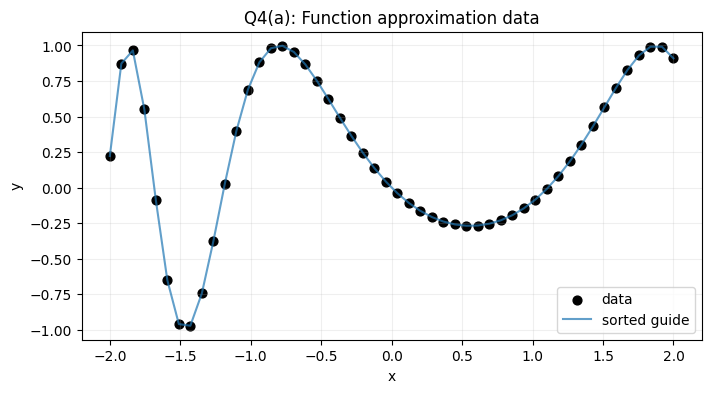

In [44]:
# Q4(a): plot the function
plot_function_1d(x, y_gt, title="Q4(a): Function approximation data")

In [45]:
def tanh(z):
    return np.tanh(z)

def d_tanh_from_output(y):
    """
    If y = tanh(z), then d/dz tanh(z) = 1 - tanh(z)^2 = 1 - y^2
    """
    return 1.0 - y**2

In [46]:
# One-hidden-layer regression network
def nn_reg_1hidden(W0, b0, W1, b1, x):
    """
    1D regression network with:
      - one hidden layer using tanh
      - one linear output neuron

    Shapes:
      x   : (N,1)
      W0  : (1,H)
      b0  : (H,)
      W1  : (H,1)
      b1  : (1,)
    """
    h = tanh(x @ W0 + b0)     # hidden activations
    y_pred = h @ W1 + b1      # linear output
    return y_pred

In [47]:
# Q4(b): initialize random network
rng = default_rng(42)

num_hidden = 10   # you can also try 5 or 8
W0 = rng.standard_normal((1, num_hidden))
b0 = rng.standard_normal(num_hidden)

W1 = rng.standard_normal((num_hidden, 1))
b1 = rng.standard_normal(1)

print("W0 shape:", W0.shape)
print("b0 shape:", b0.shape)
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)

W0 shape: (1, 10)
b0 shape: (10,)
W1 shape: (10, 1)
b1 shape: (1,)


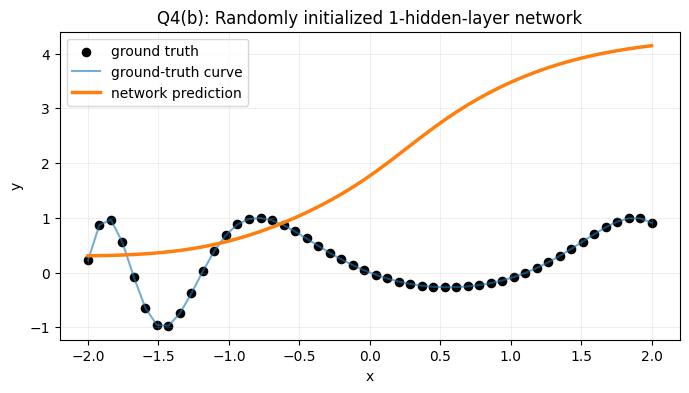

In [48]:
y_pred_random = nn_reg_1hidden(W0, b0, W1, b1, x)

plot_prediction_1d(
    x, y_gt, y_pred_random,
    title="Q4(b): Randomly initialized 1-hidden-layer network"
)

In [49]:
print("Random-model MSE:", np.mean((y_gt - y_pred_random) ** 2))

Random-model MSE: 5.3072615701690555


In [50]:
# Backpropagation for one sample: 1 hidden layer- Compute prediction, error, and gradients for 1 sample
def gradients_single_sample_q4b(x_i, y_true, W0, b0, W1, b1):
    """
    x_i    : shape (1,1)
    y_true : shape (1,1)
    """
    # Forward pass
    h = tanh(x_i @ W0 + b0)   # shape (1,H)
    y_pred = h @ W1 + b1      # shape (1,1), linear output

    # Sample squared error
    error = y_pred - y_true
    err = (error ** 2).item()

    # Output layer (linear output neuron)
    # dE/dy_pred = 2 * (y_pred - y_true)
    delta_out = 2.0 * error                 # shape (1,1)

    grad_W1 = h.T @ delta_out               # shape (H,1)
    grad_b1 = delta_out.ravel()             # shape (1,)

    # Hidden layer
    delta0 = (delta_out @ W1.T) * d_tanh_from_output(h)   # shape (1,H)

    grad_W0 = x_i.T @ delta0               # shape (1,H)
    grad_b0 = delta0.ravel()               # shape (H,)

    return y_pred, err, grad_W0, grad_b0, grad_W1, grad_b1

In [51]:
test_idx = 0
x_i = x[test_idx:test_idx+1]       # shape (1,1)
y_i = y_gt[test_idx:test_idx+1]    # shape (1,1)

y_pred_0, err_0, grad_W0_0, grad_b0_0, grad_W1_0, grad_b1_0 = gradients_single_sample_q4b(
    x_i, y_i, W0, b0, W1, b1
)

print("sample x_i:", x_i)
print("sample y_true:", y_i)
print("sample y_pred:", y_pred_0)
print("sample error:", err_0)
print("grad_W0 shape:", grad_W0_0.shape)
print("grad_b0 shape:", grad_b0_0.shape)
print("grad_W1 shape:", grad_W1_0.shape)
print("grad_b1 shape:", grad_b1_0.shape)

sample x_i: [[-2.]]
sample y_true: [[0.22288991]]
sample y_pred: [[0.30746238]]
sample error: 0.007152502508605083
grad_W0 shape: (1, 10)
grad_b0 shape: (10,)
grad_W1 shape: (10, 1)
grad_b1 shape: (1,)


In [52]:
# Q4(b): train one-hidden-layer network
rng = default_rng(42)

num_hidden = 10
W0 = rng.standard_normal((1, num_hidden))
b0 = rng.standard_normal(num_hidden)
W1 = rng.standard_normal((num_hidden, 1))
b1 = rng.standard_normal(1)

num_samples = len(x)
num_train_iterations = 100_000
eta = 0.1

error_history_b = np.zeros(num_train_iterations)

for i in range(num_train_iterations):
    # Pick one random training sample
    idx = rng.integers(0, num_samples)

    x_i = x[idx:idx+1]
    y_i = y_gt[idx:idx+1]

    y_pred_i, err_i, grad_W0, grad_b0, grad_W1, grad_b1 = gradients_single_sample_q4b(
        x_i, y_i, W0, b0, W1, b1
    )

    # Gradient descent update
    W1 -= eta * grad_W1
    b1 -= eta * grad_b1
    W0 -= eta * grad_W0
    b0 -= eta * grad_b0
    error_history_b[i] = err_i

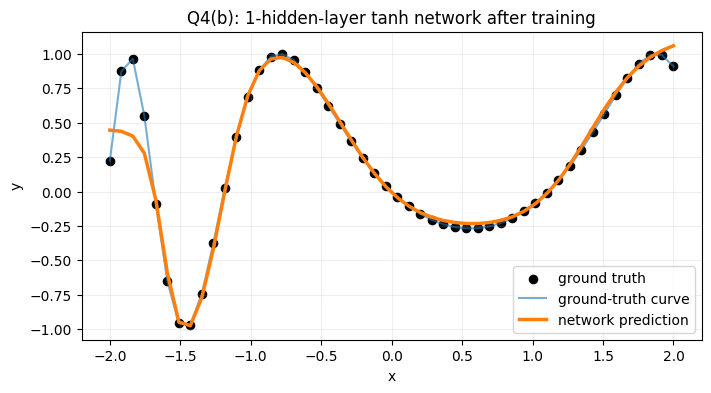

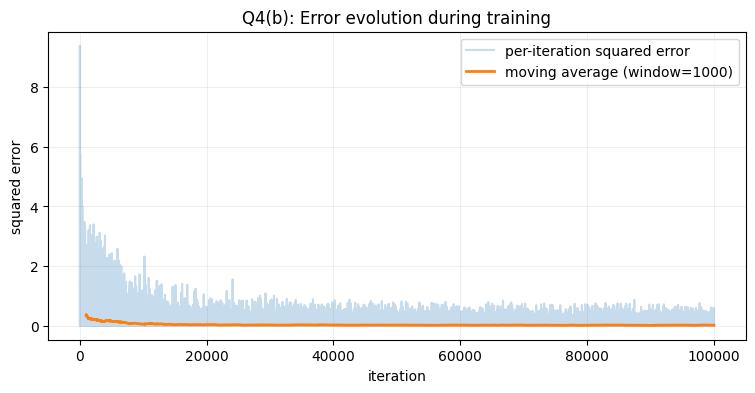

Final training MSE (Q4b): 0.013429215959673908


In [53]:
y_pred_trained_b = nn_reg_1hidden(W0, b0, W1, b1, x)

plot_prediction_1d(
    x, y_gt, y_pred_trained_b,
    title="Q4(b): 1-hidden-layer tanh network after training"
)

plot_error_history(
    error_history_b,
    title="Q4(b): Error evolution during training",
    window=1000
)

print("Final training MSE (Q4b):", np.mean((y_gt - y_pred_trained_b) ** 2))

In [54]:
# Two-hidden-layer regression network
def nn_reg_2hidden(W0, b0, W1, b1, W2, b2, x):
    """
    1D regression network with:
      - hidden layer 1 using tanh
      - hidden layer 2 using tanh
      - linear output neuron

    Shapes:
      x   : (N,1)
      W0  : (1,H1)
      b0  : (H1,)
      W1  : (H1,H2)
      b1  : (H2,)
      W2  : (H2,1)
      b2  : (1,)
    """
    h1 = tanh(x @ W0 + b0)
    h2 = tanh(h1 @ W1 + b1)
    y_pred = h2 @ W2 + b2
    return y_pred

In [55]:
# Backpropagation for one sample: 2 hidden layers
def gradients_single_sample_q4c(x_i, y_true, W0, b0, W1, b1, W2, b2):
    """
    Compute prediction, error, and gradients for ONE sample
    for a network with two tanh hidden layers.
    """
    # Forward pass
    h1 = tanh(x_i @ W0 + b0)     # (1,H1)
    h2 = tanh(h1 @ W1 + b1)      # (1,H2)
    y_pred = h2 @ W2 + b2        # (1,1), linear output

    error = y_pred - y_true
    err = (error ** 2).item()

    # Output layer
    delta2 = 2.0 * error         # linear output derivative = 1

    grad_W2 = h2.T @ delta2
    grad_b2 = delta2.ravel()

    # Hidden layer 2
    delta1 = (delta2 @ W2.T) * d_tanh_from_output(h2)

    grad_W1 = h1.T @ delta1
    grad_b1 = delta1.ravel()

    # Hidden layer 1
    delta0 = (delta1 @ W1.T) * d_tanh_from_output(h1)

    grad_W0 = x_i.T @ delta0
    grad_b0 = delta0.ravel()

    return y_pred, err, grad_W0, grad_b0, grad_W1, grad_b1, grad_W2, grad_b2

In [56]:
# Q4(c): initialize 2-hidden-layer network
rng = default_rng(42)

num_hidden_1 = 8
num_hidden_2 = 6

W0 = rng.standard_normal((1, num_hidden_1))
b0 = rng.standard_normal(num_hidden_1)

W1 = rng.standard_normal((num_hidden_1, num_hidden_2))
b1 = rng.standard_normal(num_hidden_2)

W2 = rng.standard_normal((num_hidden_2, 1))
b2 = rng.standard_normal(1)

print("W0 shape:", W0.shape)
print("b0 shape:", b0.shape)
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W0 shape: (1, 8)
b0 shape: (8,)
W1 shape: (8, 6)
b1 shape: (6,)
W2 shape: (6, 1)
b2 shape: (1,)


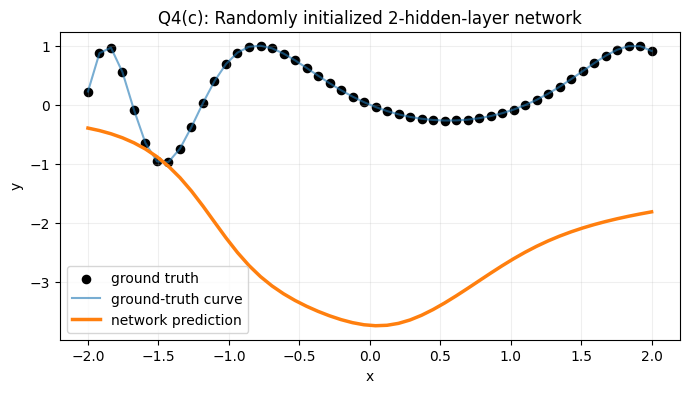

In [57]:
# Random prediction before training
y_pred_random_c = nn_reg_2hidden(W0, b0, W1, b1, W2, b2, x)

plot_prediction_1d(
    x, y_gt, y_pred_random_c,
    title="Q4(c): Randomly initialized 2-hidden-layer network"
)

In [58]:
print("Random-model MSE:", np.mean((y_gt - y_pred_random_c) ** 2))

Random-model MSE: 8.36712155841493


In [59]:
# Q4(c): train two-hidden-layer network
rng = default_rng(42)

num_hidden_1 = 8
num_hidden_2 = 6

W0 = rng.standard_normal((1, num_hidden_1))
b0 = rng.standard_normal(num_hidden_1)

W1 = rng.standard_normal((num_hidden_1, num_hidden_2))
b1 = rng.standard_normal(num_hidden_2)

W2 = rng.standard_normal((num_hidden_2, 1))
b2 = rng.standard_normal(1)

num_samples = len(x)
num_train_iterations = 100_000
eta = 0.05   # 0.1 can also work, but 0.05 is often more stable here

error_history_c = np.zeros(num_train_iterations)

for i in range(num_train_iterations):
    idx = rng.integers(0, num_samples)

    x_i = x[idx:idx+1]
    y_i = y_gt[idx:idx+1]

    (
        y_pred_i, err_i,
        grad_W0, grad_b0,
        grad_W1, grad_b1,
        grad_W2, grad_b2
    ) = gradients_single_sample_q4c(x_i, y_i, W0, b0, W1, b1, W2, b2)

    # Gradient descent update
    W2 -= eta * grad_W2
    b2 -= eta * grad_b2
    W1 -= eta * grad_W1
    b1 -= eta * grad_b1
    W0 -= eta * grad_W0
    b0 -= eta * grad_b0

    error_history_c[i] = err_i

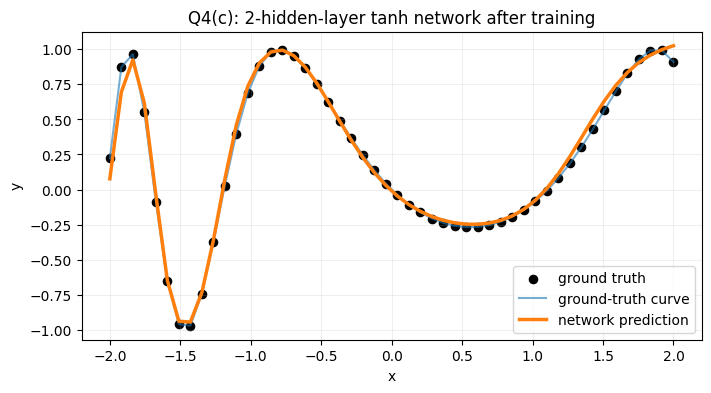

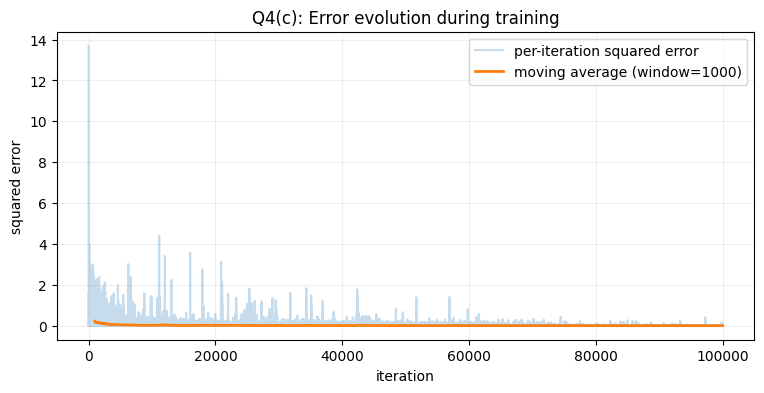

Final training MSE (Q4c): 0.002212007042820973


In [60]:
# Final function approximation after training
y_pred_trained_c = nn_reg_2hidden(W0, b0, W1, b1, W2, b2, x)

plot_prediction_1d(
    x, y_gt, y_pred_trained_c,
    title="Q4(c): 2-hidden-layer tanh network after training"
)

plot_error_history(
    error_history_c,
    title="Q4(c): Error evolution during training",
    window=1000
)

print("Final training MSE (Q4c):", np.mean((y_gt - y_pred_trained_c) ** 2))

----------------------------------------------------------------------------------------------------------------------------